# Capstone Function 7
You’re tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function. 

Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance.

 Input | Output | Goal |
|-------|--------|------|
| 6D Array (30, 6) | 1D Array (30, ) | Maximise |

## Initial Submission

Bayesian Optimization for 6D ML model hyperparameter tuning (learning rate, regularization, layers, etc.).

### Step 1: Setup

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
print("Setup complete!")

### Step 2: Load Data & Initial Analysis

In [ ]:
X_init = np.load('../../data/f7/updated_inputs - Week 4.npy')
y_init = np.load('../../data/f7/updated_outputs - Week 4.npy')
hyperparam_names = ['Learning Rate', 'Reg Strength', 'Layers', 'Dropout', 'Batch Size', 'Optimizer']
print(f"6D ML Hyperparameter Data: {X_init.shape}")
print(f"Best performance: {y_init.max():.6f}")
print(f"Output range: [{y_init.min():.6f}, {y_init.max():.6f}]")

In [ ]:
# Visualize subset of pairs
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
pairs = [(0,1), (0,2), (1,3), (2,4), (3,5), (4,5)]
for idx, (i, j) in enumerate(pairs):
    axes[idx].scatter(X_init[:, i], X_init[:, j], c=y_init, cmap='coolwarm', edgecolors='black', s=50)
    axes[idx].set_xlabel(hyperparam_names[i], fontsize=9)
    axes[idx].set_ylabel(hyperparam_names[j], fontsize=9)
    axes[idx].grid(True, alpha=0.3)
plt.suptitle('6D ML Hyperparameter Space - Selected Pairs', fontweight='bold')
plt.tight_layout()
plt.show()

### Step 3: Hyperparameters & Optimization

**6D Space:** Restarts: 25, Raw: 3072 (higher dimensional requires more thorough search)

In [ ]:
# All inputs must be in range [0, 1.0] per submission requirements
N_DIM = X_init.shape[1]
BOUNDS = torch.tensor([[0.0] * N_DIM, [1.0] * N_DIM], dtype=torch.float64)
NUM_RESTARTS, RAW_SAMPLES = 25, 3072
X_train = torch.tensor(X_init, dtype=torch.float64)
y_train = torch.tensor(y_init, dtype=torch.float64).unsqueeze(-1)
gp_model = SingleTaskGP(X_train, y_train)
mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)
fit_gpytorch_mll(mll)
EI = ExpectedImprovement(gp_model, best_f=y_train.max().item())
candidate, acq_value = optimize_acqf(EI, bounds=BOUNDS, q=1, num_restarts=NUM_RESTARTS, raw_samples=RAW_SAMPLES)
next_point = candidate.detach().numpy()[0]
print(f"✓ Next config: {dict(zip(hyperparam_names, next_point))}")

### Step 4: Analysis & Visualization

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Safe lengthscale access (kernel structure may vary)
if hasattr(gp_model.covar_module, 'base_kernel'):
    ls = gp_model.covar_module.base_kernel.lengthscale.detach().numpy()[0]
else:
    ls = gp_model.covar_module.lengthscale.detach().numpy()[0]

ax1.barh(hyperparam_names, ls, color='teal', edgecolor='black')
ax1.set_xlabel('Lengthscale (smaller = more important)')
ax1.set_title('Hyperparameter Sensitivity', fontweight='bold')

best_so_far = np.maximum.accumulate(y_init)
ax2.plot(range(1, len(best_so_far)+1), best_so_far, 'g-o', linewidth=2)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Best Model Performance')
ax2.set_title('Optimization Progress', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Next submission: {next_point}")

### Visualize Expected Improvement

For higher-dimensional spaces, we visualize 1D slices of the acquisition function.
Each plot shows how EI changes along one dimension while others are fixed at the proposed point.

In [ ]:
# 1D marginal plots of Expected Improvement
n_points = 100
n_dims = len(next_point)

fig, axes = plt.subplots(1, n_dims, figsize=(4*n_dims, 4))
if n_dims == 1:
    axes = [axes]

for dim in range(n_dims):
    # Create points varying along this dimension
    X_marginal = np.tile(next_point, (n_points, 1))
    X_marginal[:, dim] = np.linspace(0, 1.0, n_points)
    X_marginal_torch = torch.tensor(X_marginal, dtype=torch.float64)
    
    # Compute EI at each point
    with torch.no_grad():
        ei_values = EI(X_marginal_torch.unsqueeze(1)).numpy()
    
    # Plot
    axes[dim].plot(X_marginal[:, dim], ei_values, 'b-', linewidth=2)
    axes[dim].axvline(next_point[dim], color='r', linestyle='--', linewidth=2, label='Proposed')
    axes[dim].set_xlabel(f'x{dim+1}', fontsize=12)
    axes[dim].set_ylabel('Expected Improvement' if dim == 0 else '', fontsize=12)
    axes[dim].set_title(f'EI along dim {dim+1}', fontsize=11, fontweight='bold')
    axes[dim].grid(True, alpha=0.3)
    if dim == 0:
        axes[dim].legend()

plt.suptitle('Expected Improvement - 1D Marginals', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Red dashed lines show the proposed next point coordinates.")
print(f"EI is maximized when considering all dimensions jointly.")

### Step 5: Format Next Query for Submission

Format the proposed next sample point in the required submission format:
- Format: `x1-x2-x3-...-xn` where each xᵢ begins with 0
- Precision: 6 decimal places per coordinate
- Range: All values clamped to [0, 1.0]

In [ ]:
# Format the next query for submission
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0, 1.0]."""
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

# Clamp next_point to valid range
next_point_clamped = np.array([max(0.0, min(1.0, x)) for x in next_point])

# Display the formatted submission query
submission_query = format_query(next_point)
print("=" * 60)
print("SUBMISSION QUERY FOR FUNCTION 7")
print("=" * 60)
print(f"\n{submission_query}\n")
print("=" * 60)
print(f"\nCoordinates breakdown:")
for i, x in enumerate(next_point, 1):
    print(f"  x{i} = {x:.6f}")
print(f"\nEI value: {acq_value.item():.6f}")
if acq_value.item() > 0.1:
    print("  -> High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  -> Moderate EI: Some exploration potential remains")
else:
    print("  -> Low EI: Approaching convergence")
print(f"Current best observed: {y_train.max().item():.6f}")

## Week 5 — Neural Network Surrogate (PyTorch)

This section replaces the Gaussian Process surrogate with a **Neural Network** model for the 6D optimization problem (f7).

**Why Neural Network for f7?**
- Neural networks can approximate arbitrarily complex functions — suited for higher-dimensional (6D) problems where GP covariance matrices become expensive
- MC Dropout provides uncertainty estimates at inference time without requiring ensemble training — each forward pass with random dropout masks produces a different prediction, and 50 passes give mean and variance
- Input gradient magnitude reveals which dimensions the network relies on most, analogous to GP lengthscales or tree feature importance
- Flexible architecture can capture non-linear interactions between input dimensions

**Architecture:** 6 -> 128 -> 64 -> 32 -> 1 (fully connected, ReLU activations, Dropout p=0.2)
**Acquisition Strategy:** UCB with MC Dropout uncertainty (mean ± kappa * std from 50 stochastic forward passes)

### Step 1: Load Data & Set Up PyTorch

Load Week 5 data (35 samples), normalize inputs/outputs, and define the neural network architecture.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Load Week 5 cumulative data
X_w5 = np.load('../../data/f7/updated_inputs - Week 5.npy')
y_w5 = np.load('../../data/f7/updated_outputs - Week 5.npy')

print(f"Week 5 Data: {X_w5.shape[0]} samples, {X_w5.shape[1]} dimensions")
print(f"Output range: [{y_w5.min():.6f}, {y_w5.max():.6f}]")
print(f"Best observed: {y_w5.max():.6f} at {X_w5[y_w5.argmax()]}")

# Normalize inputs and outputs for training stability
X_mean, X_std = X_w5.mean(axis=0), X_w5.std(axis=0) + 1e-8
y_mean, y_std = y_w5.mean(), y_w5.std() + 1e-8

X_norm = (X_w5 - X_mean) / X_std
y_norm = (y_w5 - y_mean) / y_std

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_tensor = torch.tensor(y_norm, dtype=torch.float32).unsqueeze(1)

# Define neural network with Dropout
class SurrogateNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 128),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = SurrogateNN()
print(f"\nModel architecture:\n{model}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):.0f}")

Week 5 Data: 35 samples, 6 dimensions
Output range: [0.002701, 2.304991]
Best observed: 2.304991 at [0.       0.261823 0.623526 0.173633 0.3524   0.687293]

Model architecture:
SurrogateNN(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total parameters: 11265


### Step 2: Neural Network Hyperparameters & Training

**Hyperparameter Choices:**
1. **Hidden layers**: 128 -> 64 -> 32 — progressively narrowing architecture captures hierarchical features
2. **Dropout = 0.2**: Applied after each hidden layer for MC Dropout uncertainty at inference
3. **Learning rate = 0.005**: Adam optimizer with moderate learning rate for 35 samples
4. **Epochs = 800**: Sufficient training iterations; loss curve monitored for convergence
5. **MC samples = 50**: Forward passes with dropout enabled at inference for uncertainty estimation
6. **UCB kappa = 2.5**: Exploration parameter scaled for 6D search space

Epoch 160/800, Loss: 0.026133
Epoch 320/800, Loss: 0.137137
Epoch 480/800, Loss: 0.025439
Epoch 640/800, Loss: 0.031698
Epoch 800/800, Loss: 0.037438


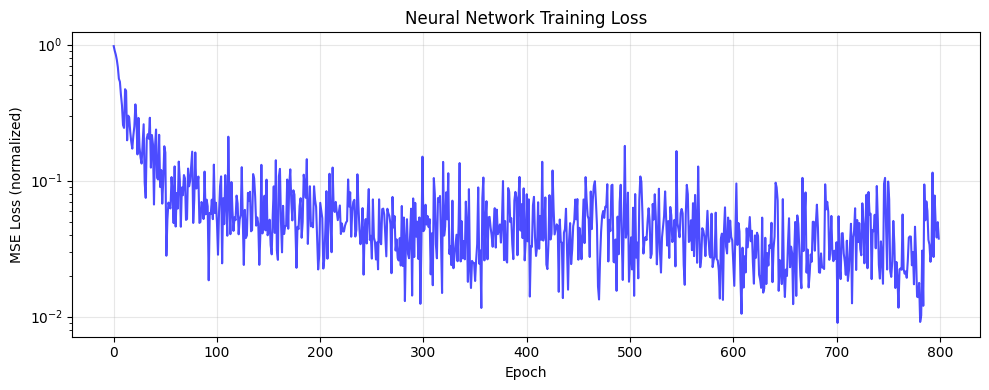


Training R²: 0.990243


In [2]:
# Training hyperparameters
LEARNING_RATE = 0.005
EPOCHS = 800
MC_SAMPLES = 50
KAPPA = 2.5
N_CANDIDATES = 20000

# Train the model
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

losses = []
model.train()
for epoch in range(EPOCHS):
    optimizer.zero_grad()
    pred = model(X_tensor)
    loss = criterion(pred, y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 160 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.6f}")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses, 'b-', alpha=0.7)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Neural Network Training Loss')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

# Final training metrics
model.eval()
with torch.no_grad():
    train_pred = model(X_tensor).squeeze().numpy()
train_pred_orig = train_pred * y_std + y_mean
train_r2 = 1 - np.sum((y_w5 - train_pred_orig)**2) / np.sum((y_w5 - y_w5.mean())**2)
print(f"\nTraining R²: {train_r2:.6f}")

### Step 3: UCB Acquisition with MC Dropout

Run 50 stochastic forward passes (dropout enabled) for each candidate point:
- **mu(x)** = mean of MC predictions
- **sigma(x)** = std of MC predictions
- **UCB(x) = mu(x) + kappa * sigma(x)** where kappa = 2.5

In [3]:
# Generate random candidate points
np.random.seed(42)
candidates = np.random.uniform(0, 1.0, size=(N_CANDIDATES, 6))

# Normalize candidates
cand_norm = (candidates - X_mean) / X_std
cand_tensor = torch.tensor(cand_norm, dtype=torch.float32)

# MC Dropout: Run model in train mode for stochastic forward passes
model.train()  # Enable dropout
mc_predictions = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model(cand_tensor).squeeze().numpy()
        mc_predictions.append(pred)

mc_predictions = np.array(mc_predictions)  # shape: (MC_SAMPLES, N_CANDIDATES)

# Denormalize predictions
mc_preds_orig = mc_predictions * y_std + y_mean

# Compute mean and uncertainty
mu = mc_preds_orig.mean(axis=0)
sigma = mc_preds_orig.std(axis=0)

# UCB acquisition
ucb = mu + KAPPA * sigma

# Select best candidate
best_idx = np.argmax(ucb)
next_point_w5 = np.clip(candidates[best_idx], 0.0, 1.0)

print("UCB Acquisition Results (MC Dropout):")
print(f"  Best UCB value:     {ucb[best_idx]:.6f}")
print(f"  MC mean prediction: {mu[best_idx]:.6f}")
print(f"  MC std (sigma):     {sigma[best_idx]:.6f}")
print(f"  Next sample point:  {next_point_w5}")
print()
print("MC prediction statistics:")
print(f"  Mean of mu:    {mu.mean():.6f}")
print(f"  Max of mu:     {mu.max():.6f}")
print(f"  Mean of sigma: {sigma.mean():.6f}")
print(f"  Max of sigma:  {sigma.max():.6f}")

UCB Acquisition Results (MC Dropout):
  Best UCB value:     2.916225
  MC mean prediction: 1.965532
  MC std (sigma):     0.380277
  Next sample point:  [0.01751046 0.21323095 0.42496709 0.04490498 0.32773348 0.88702482]

MC prediction statistics:
  Mean of mu:    0.205756
  Max of mu:     1.970783
  Mean of sigma: 0.072960
  Max of sigma:  0.409788


### Step 4: Feature Importance via Input Gradients

Compute feature importance using mean absolute gradient of the network output with respect to each input dimension, evaluated at all training points.

In [4]:
# Feature importance via input gradient magnitude
model.eval()
X_grad = torch.tensor(X_norm, dtype=torch.float32, requires_grad=True)
output = model(X_grad).sum()
output.backward()

# Mean absolute gradient per dimension
grad_importance = X_grad.grad.abs().mean(dim=0).numpy()
grad_importance = grad_importance / grad_importance.sum()  # Normalize to sum to 1

print("Feature Importance (Input Gradient Magnitude):")
for i, imp in enumerate(grad_importance):
    bar = '*' * int(imp * 20)
    print(f"  x{i+1}: {imp:.4f} ({bar})")

Feature Importance (Input Gradient Magnitude):
  x1: 0.1890 (***)
  x2: 0.2516 (*****)
  x3: 0.1544 (***)
  x4: 0.1819 (***)
  x5: 0.0905 (*)
  x6: 0.1328 (**)


### Step 5: Visualize Neural Network Surrogate

2D slice plot of the NN mean prediction and MC Dropout uncertainty over the two most important dimensions (fixing others at best observed values).

Top 2 dimensions: x1 (imp=0.1890), x2 (imp=0.2516)
Fixed dimensions: x3=0.6235, x4=0.1736, x5=0.3524, x6=0.6873


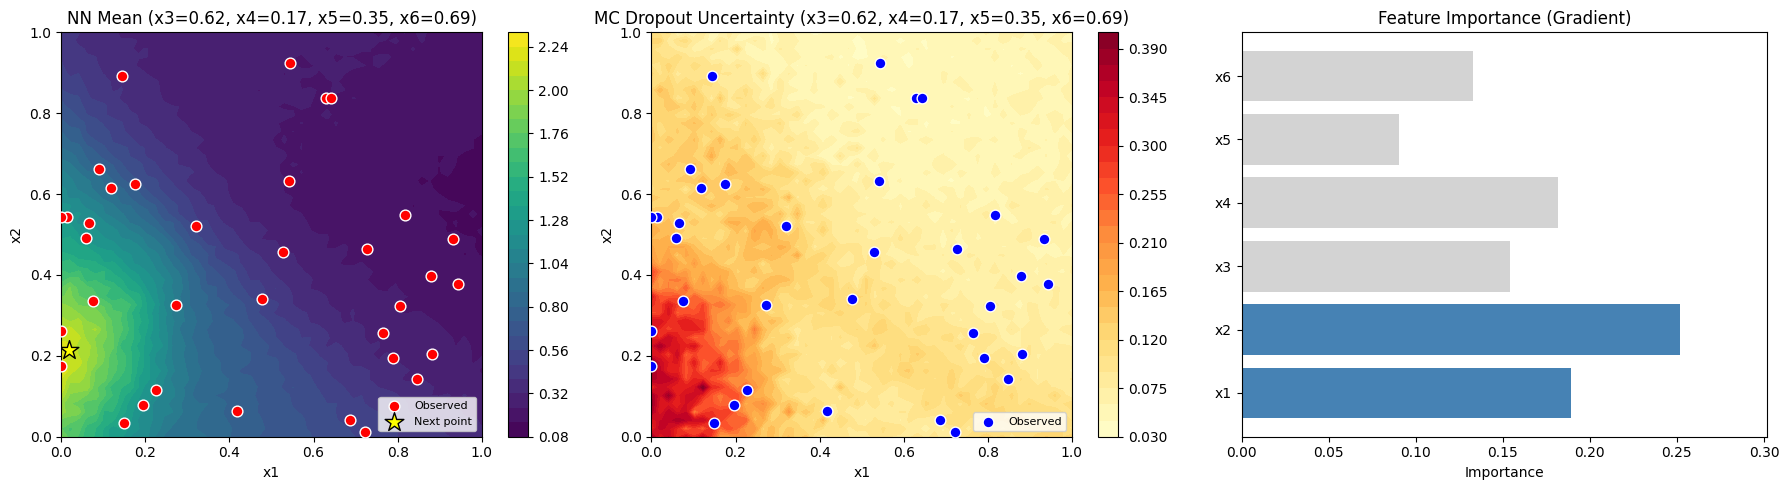

In [5]:
# Top 2 dimensions by gradient importance
top2 = np.argsort(grad_importance)[-2:]
fixed_dims = [d for d in range(6) if d not in top2]
best_point = X_w5[y_w5.argmax()]

print(f"Top 2 dimensions: x{top2[0]+1} (imp={grad_importance[top2[0]]:.4f}), x{top2[1]+1} (imp={grad_importance[top2[1]]:.4f})")
print(f"Fixed dimensions: " + ", ".join([f"x{d+1}={best_point[d]:.4f}" for d in fixed_dims]))

# Create 2D grid
n_grid = 50
d0_grid = np.linspace(0, 1, n_grid)
d1_grid = np.linspace(0, 1, n_grid)
D0, D1 = np.meshgrid(d0_grid, d1_grid)

# Build full grid points
grid_points = np.zeros((n_grid * n_grid, 6))
grid_points[:, top2[0]] = D0.ravel()
grid_points[:, top2[1]] = D1.ravel()
for d in fixed_dims:
    grid_points[:, d] = best_point[d]

# Normalize and predict with MC Dropout
grid_norm = (grid_points - X_mean) / X_std
grid_tensor = torch.tensor(grid_norm, dtype=torch.float32)

model.train()  # Enable dropout for MC
grid_mc = []
with torch.no_grad():
    for _ in range(MC_SAMPLES):
        pred = model(grid_tensor).squeeze().numpy()
        grid_mc.append(pred)
grid_mc = np.array(grid_mc) * y_std + y_mean

grid_mu = grid_mc.mean(axis=0).reshape(n_grid, n_grid)
grid_sigma = grid_mc.std(axis=0).reshape(n_grid, n_grid)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: NN mean prediction
ax1 = axes[0]
c1 = ax1.contourf(D0, D1, grid_mu, levels=30, cmap='viridis')
ax1.scatter(X_w5[:, top2[0]], X_w5[:, top2[1]], c='red', edgecolors='white', s=60, zorder=5, label='Observed')
ax1.scatter(next_point_w5[top2[0]], next_point_w5[top2[1]], c='yellow', marker='*', s=200, edgecolors='black', zorder=6, label='Next point')
fixed_str = ", ".join([f"x{d+1}={best_point[d]:.2f}" for d in fixed_dims])
ax1.set_xlabel(f'x{top2[0]+1}'); ax1.set_ylabel(f'x{top2[1]+1}')
ax1.set_title(f'NN Mean ({fixed_str})')
ax1.legend(loc='lower right', fontsize=8)
plt.colorbar(c1, ax=ax1)

# Plot 2: MC Dropout uncertainty
ax2 = axes[1]
c2 = ax2.contourf(D0, D1, grid_sigma, levels=30, cmap='YlOrRd')
ax2.scatter(X_w5[:, top2[0]], X_w5[:, top2[1]], c='blue', edgecolors='white', s=60, zorder=5, label='Observed')
ax2.set_xlabel(f'x{top2[0]+1}'); ax2.set_ylabel(f'x{top2[1]+1}')
ax2.set_title(f'MC Dropout Uncertainty ({fixed_str})')
ax2.legend(loc='lower right', fontsize=8)
plt.colorbar(c2, ax=ax2)

# Plot 3: Feature importance
ax3 = axes[2]
dims = [f'x{i+1}' for i in range(6)]
colors = ['steelblue' if i in top2 else 'lightgray' for i in range(6)]
ax3.barh(dims, grad_importance, color=colors)
ax3.set_xlabel('Importance')
ax3.set_title('Feature Importance (Gradient)')
ax3.set_xlim(0, max(grad_importance) * 1.2)

plt.tight_layout()
plt.show()

### Step 6: Convergence Plot

Running maximum (best observed value) across all observations.

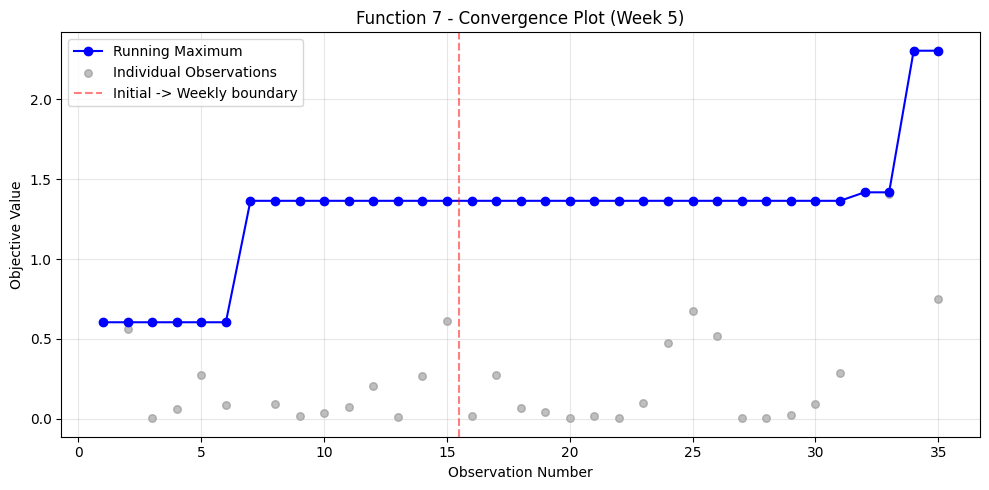

Best observed value: 2.304991
Achieved at observation: 34


In [6]:
# Convergence plot
running_max = np.maximum.accumulate(y_w5)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y_w5) + 1), running_max, 'b-o', markersize=6, label='Running Maximum')
plt.scatter(range(1, len(y_w5) + 1), y_w5, c='gray', alpha=0.5, s=30, label='Individual Observations')
plt.axvline(x=15.5, color='red', linestyle='--', alpha=0.5, label='Initial -> Weekly boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 7 - Convergence Plot (Week 5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y_w5.max():.6f}")
print(f"Achieved at observation: {y_w5.argmax() + 1}")

### Step 7: Format Submission Query

Format the proposed next sample point as `x1-x2-x3-x4-x5-x6` with 6 decimal places.

In [7]:
# Format submission query
def format_query(point):
    clamped = [max(0.0, min(1.0, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

submission_query_w5 = format_query(next_point_w5)

print("=" * 60)
print("WEEK 5 SUBMISSION QUERY FOR FUNCTION 7")
print("=" * 60)
print(f"Surrogate: Neural Network ({model.__class__.__name__})")
print(f"Architecture: 6 -> 128 -> 64 -> 32 -> 1")
print(f"Dropout: 0.2, MC samples: {MC_SAMPLES}")
print(f"Acquisition: UCB (kappa={KAPPA})")
print(f"Training R²: {train_r2:.6f}")
print(f"Next point: {next_point_w5}")
print(f"MC mean: {mu[best_idx]:.6f}")
print(f"MC std:  {sigma[best_idx]:.6f}")
print(f"")
print(f">>> SUBMISSION: {submission_query_w5}")
print("=" * 60)

WEEK 5 SUBMISSION QUERY FOR FUNCTION 7
Surrogate: Neural Network (SurrogateNN)
Architecture: 6 -> 128 -> 64 -> 32 -> 1
Dropout: 0.2, MC samples: 50
Acquisition: UCB (kappa=2.5)
Training R²: 0.990243
Next point: [0.01751046 0.21323095 0.42496709 0.04490498 0.32773348 0.88702482]
MC mean: 1.965532
MC std:  0.380277

>>> SUBMISSION: 0.017510-0.213231-0.424967-0.044905-0.327733-0.887025


### Model Comparison

**Neural Network vs GP (Initial Section):**
- GP with Matern 5/2 and ARD for 6D faces the curse of dimensionality — the covariance matrix is 35×35, still tractable but lengthscale optimization in 6D is challenging.
- The NN's deeper architecture (128→64→32) captures hierarchical feature interactions that GP's stationary kernel may miss.
- MC Dropout with 50 passes provides diversity-based uncertainty similar to GP's posterior variance, though less principled.
- For f7's 6D problem, the NN can model non-stationary behavior where different regions of the space have different complexity.
- Key trade-off: GP gives exact posterior for stationary functions; NN handles non-stationarity and higher dimensions better.